# CM Market Summary

This notebook summarizes the capacity market outputs only. It shows the net capacity position by zone for explicit FBMC and NTC. Positive values mean net import need; negative values mean net export surplus. The saved outputs are zone-level, so the figures show net positions rather than exact bilateral counterparties.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import display

REPO_DIR = Path(r'c:\Users\Administrator\OneDrive\Thesis Code\cross_border-CM-analysis')
DATA_DIR = REPO_DIR / 'analysis_data'
ZONES = ['A', 'B', 'C']
DESIGNS = ['FBMC', 'NTC']

def load_cm_zone(design: str, zone: str) -> pd.DataFrame:
    path = DATA_DIR / f'explicit_{design}' / f'mcp_zone_{zone}_{design}.csv'
    if not path.exists():
        raise FileNotFoundError(path)
    df = pd.read_csv(path, sep=';')
    demand_col = f'CapDemand_Cons_{zone}'
    if demand_col not in df.columns:
        raise KeyError(f'Missing {demand_col} in {path.name}')
    out = pd.DataFrame({
        'Timestep': df['Timestep'],
        'Zone': zone,
        'Design': design,
        'CM_price': df['CM_price'],
        'TotalCapOffer': df['TotalCapOffer'],
        'CapDemand': df[demand_col],
        'NetCapacityPosition_MW': df['CapacityManager'],
        'NetworkManager': df['NetworkManager'],
    })
    return out

cm = pd.concat([load_cm_zone(d, z) for d in DESIGNS for z in ZONES], ignore_index=True)
summary = (
    cm.groupby(['Design', 'Zone'], as_index=False)
      .agg(CM_price_mean=('CM_price', 'mean'),
           TotalCapOffer_mean=('TotalCapOffer', 'mean'),
           CapDemand_mean=('CapDemand', 'mean'),
           NetCapacityPosition_MW=('NetCapacityPosition_MW', 'mean'))
)
summary['Direction'] = np.where(summary['NetCapacityPosition_MW'] > 1e-9, 'Importer',
                              np.where(summary['NetCapacityPosition_MW'] < -1e-9, 'Exporter', 'Balanced'))
summary['NetDirectionText'] = summary['Direction'] + ' (' + summary['NetCapacityPosition_MW'].round(1).astype(str) + ' MW)'

display(summary.sort_values(['Design', 'Zone']).style.format({
    'CM_price_mean': '{:.2f}',
    'TotalCapOffer_mean': '{:.1f}',
    'CapDemand_mean': '{:.1f}',
    'NetCapacityPosition_MW': '{:+.1f}'
}).hide(axis='index').set_caption('Capacity market summary by zone and design'))

for design in DESIGNS:
    sub = summary[summary['Design'] == design].copy()
    exporters = sub.loc[sub['NetCapacityPosition_MW'] < -1e-9, 'Zone'].tolist()
    importers = sub.loc[sub['NetCapacityPosition_MW'] > 1e-9, 'Zone'].tolist()
    print(f'{design}: exporters={exporters}, importers={importers}')


Design,Zone,CM_price_mean,TotalCapOffer_mean,CapDemand_mean,NetCapacityPosition_MW,Direction,NetDirectionText
FBMC,A,70000.00,17253.2,16387.3,-865.9,Exporter,Exporter (-865.9 MW)
FBMC,B,69999.99,14001.2,13593.4,-407.8,Exporter,Exporter (-407.8 MW)
FBMC,C,70000.00,16500.4,17774.2,+1273.7,Importer,Importer (1273.7 MW)
NTC,A,70000.00,16559.8,16387.3,-172.5,Exporter,Exporter (-172.5 MW)
NTC,B,69999.99,13997.2,13593.4,-403.8,Exporter,Exporter (-403.8 MW)
NTC,C,70000.00,17197.8,17774.2,+576.3,Importer,Importer (576.3 MW)


FBMC: exporters=['A', 'B'], importers=['C']
NTC: exporters=['A', 'B'], importers=['C']


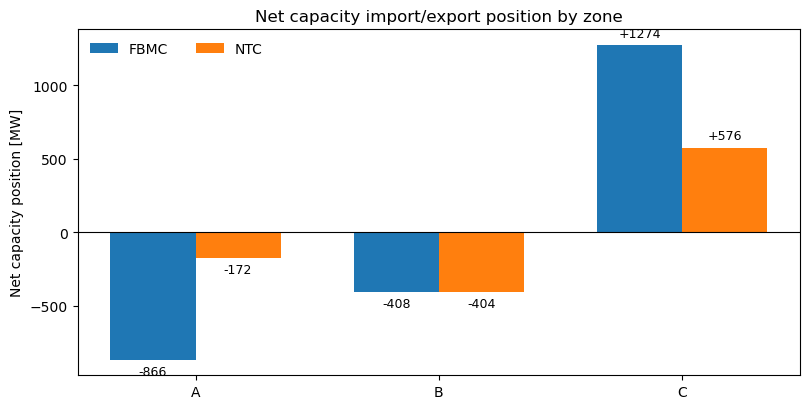

In [2]:
# Figure 1: net capacity position by zone
pivot_net = summary.pivot(index='Zone', columns='Design', values='NetCapacityPosition_MW').reindex(ZONES)
x = np.arange(len(ZONES))
width = 0.35
fig, ax = plt.subplots(figsize=(8.2, 4.2))
for i, design in enumerate(DESIGNS):
    vals = pivot_net[design].values
    offset = (i - (len(DESIGNS) - 1) / 2) * width
    color = '#1f77b4' if design == 'FBMC' else '#ff7f0e'
    ax.bar(x + offset, vals, width=width, label=design, color=color)
ax.axhline(0, color='black', lw=0.8)
ax.set_xticks(x)
ax.set_xticklabels(ZONES)
ax.set_ylabel('Net capacity position [MW]')
ax.set_title('Net capacity import/export position by zone')
ax.legend(frameon=False, ncol=2)
for i, design in enumerate(DESIGNS):
    vals = pivot_net[design].values
    offset = (i - (len(DESIGNS) - 1) / 2) * width
    for j, v in enumerate(vals):
        ax.text(x[j] + offset, v + (35 if v >= 0 else -35), f'{v:+.0f}', ha='center', va='bottom' if v >= 0 else 'top', fontsize=9)
plt.tight_layout()
plt.show()


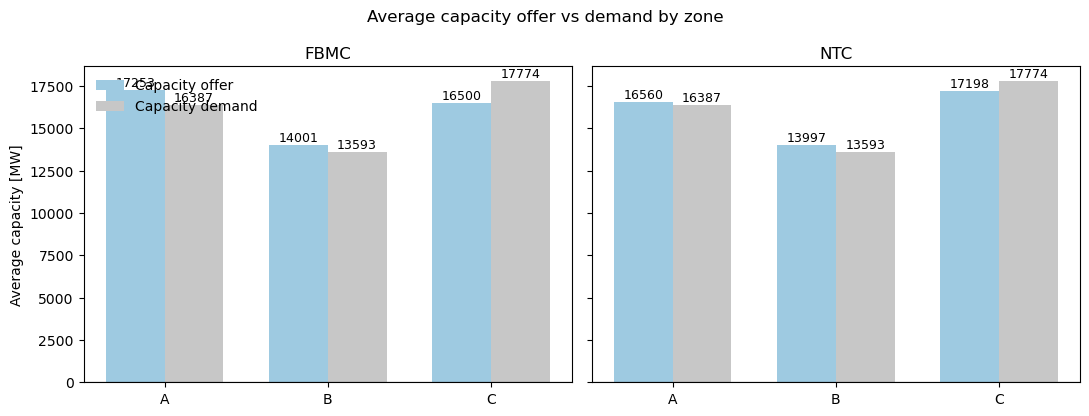

In [3]:
# Figure 2: average capacity offer vs demand by zone
offer_pivot = summary.pivot(index='Zone', columns='Design', values='TotalCapOffer_mean').reindex(ZONES)
demand_pivot = summary.pivot(index='Zone', columns='Design', values='CapDemand_mean').reindex(ZONES)
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), sharey=True)
for ax, design in zip(axes, DESIGNS):
    offer = offer_pivot[design].values
    demand = demand_pivot[design].values
    x = np.arange(len(ZONES))
    w = 0.36
    ax.bar(x - w/2, offer, width=w, label='Capacity offer', color='#9ecae1')
    ax.bar(x + w/2, demand, width=w, label='Capacity demand', color='#c7c7c7')
    ax.set_title(design)
    ax.set_xticks(x)
    ax.set_xticklabels(ZONES)
    ax.axhline(0, color='black', lw=0.8)
    for j, (o, d) in enumerate(zip(offer, demand)):
        ax.text(j - w/2, o + 40, f'{o:.0f}', ha='center', va='bottom', fontsize=9)
        ax.text(j + w/2, d + 40, f'{d:.0f}', ha='center', va='bottom', fontsize=9)
axes[0].set_ylabel('Average capacity [MW]')
axes[0].legend(frameon=False, loc='upper left')
fig.suptitle('Average capacity offer vs demand by zone')
plt.tight_layout()
plt.show()


### Interpretation
The explicit CM outputs provide zone-level net positions, not a full bilateral counterparty matrix. In these runs, A and B are net exporters and C is the net importer for both FBMC and NTC. The figures therefore show the direction and size of the net CM balance by zone.
